# MedProc Training Pipeline
## Modular Medical Information Processing — Training Execution

**Objectives:**
1. Load and preprocess medical text datasets
2. Define two-task Bio_ClinicalBERT model (ICD classification + Symptom/Evolution relevance)
3. Train with weighted multi-task loss
4. Evaluate ICD and symptom prediction performance on validation set
5. Visualize training progress
6. Save checkpoint for IT-Fusion (Stage 6) inference

**Stage 5 outputs consumed by IT-Fusion:**
- `evolution_score` — the E value in ABCDE scoring
- `symptom_keywords` — matched clinical keywords from the note

**Not in scope here:** Drug recommendation is handled by `drug_rules.py` in Stage 6 using HC lesion-class output, not MedProc text output.

**Project:** NutriDermAI — Stage 5 Medical Information Processing

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Setup: Imports & Modular Code Loading
# ─────────────────────────────────────────────────────────────────────────────

import sys
from pathlib import Path

# Add MedProc module to path
MEDPROC_DIR = Path('/home/vjti-comp/Desktop/Final Project Code/MedProc')
sys.path.insert(0, str(MEDPROC_DIR))

# Import custom modules
from medproc_dataset import *
from medproc_model import *

import torch
import torch.nn as nn
from transformers import AutoTokenizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Setup plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print('✓ All modules imported successfully')
print(f'  Device: {DEVICE}')
print(f'  Model: {MODEL_NAME}')

✓ All modules imported successfully
  Device: cuda
  Model: emilyalsentzer/Bio_ClinicalBERT


## Section 1: Load and Prepare Dataset

Load medical text from source, clean, preprocess, and split into training/validation sets.

In [2]:
# Load dataset from parquet
combined_path = OUTPUT_DIR / 'medproc_combined.parquet'

if not combined_path.exists():
    print('⚠️  Dataset not found at:', combined_path)
    print('   Using sample data for demonstration...')
    # Create minimal sample dataset for demo
    df = pd.DataFrame({
        'TEXT': [
            'Patient with growing lesion on arm. Spreading over 3 months. '
            'Color changes noted. Itching and bleeding.',
            'History of hypertension. On lisinopril. No skin changes. '
            'Routine follow-up.',
        ],
        'icd_prefix': ['172', '401'],
    })
    print(f'✓ Created demo dataset: {len(df)} records')
else:
    print(f'Loading dataset from {combined_path}...')
    combined = dd.read_parquet(str(combined_path))
    df = combined.compute()
    print(f'✓ Loaded {len(df):,} records')

# Display sample
print(f'\nSample record:')
print(df.iloc[0])
print(f'\nDataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')


Loading dataset from /data/Stagewise Dataset/MedProc/final5/medproc_combined.parquet...
✓ Loaded 80,284 records

Sample record:
TEXT           Hospital Course: 82 y/o female admitted for co...
ICD9_CODE                                                   5185
DRUG           ["Nystatin Cream", "Ketorolac", "Bupivacaine 0...
GENDER                                                         F
note_length                                                 3000
source                                                    mimic3
Name: 0, dtype: object

Dataset shape: (80284, 6)
Columns: ['TEXT', 'ICD9_CODE', 'DRUG', 'GENDER', 'note_length', 'source']


In [3]:
# Data preprocessing
print('Preprocessing dataset...')
print(f'Available columns: {df.columns.tolist()}')

# Clean and truncate text
df['TEXT'] = df['TEXT'].apply(clean_text)
df['TEXT'] = df['TEXT'].apply(lambda x: smart_truncate(x, MAX_TEXT_LENGTH))

# Symptom label — 1 if the note contains any symptom/evolution keywords
# This is the label that trains the symptom_head to detect Evolution (E) signals.
# NOTE: Drug presence in the note is NOT used here — drug recommendation is
# handled by drug_rules.py in Stage 6 using HC lesion-class output.
# Use EVOLUTION_KEYWORDS (skin-specific) not full SYMPTOM_KEYWORDS
# Full list includes 'months','weeks' etc. which appear in 87%+ of all notes
# → sym_head would learn 'time word present?' not 'skin lesion changing?'
df['has_symptom'] = df['TEXT'].apply(
    lambda t: 1 if extract_evolution_signals(t) else 0
)
print(f'  → Created has_symptom from EVOLUTION_KEYWORDS (skin-specific)')
print(f'  → Notes with evolution signals: {df["has_symptom"].sum()} / {len(df)}')
print(f'  → Evolution signal rate: {df["has_symptom"].mean():.2%} (expect 20-40% for good signal)')

# ICD multi-label encoding
if 'icd_prefix' not in df.columns:
    if 'ICD9_CODE' in df.columns:
        df['icd_prefix'] = df['ICD9_CODE'].astype(str).str.split('.').str[0]
        print('  → Extracted icd_prefix from ICD9_CODE')
    else:
        print('  ⚠️  Neither icd_prefix nor ICD9_CODE found, creating dummy values...')
        df['icd_prefix'] = ['172' if i % 2 == 0 else '401' for i in range(len(df))]

# Filter to relevant ICD codes
df = df[df['icd_prefix'].apply(icd_is_relevant)].reset_index(drop=True)
print(f'  → Filtered to {len(df):,} records with relevant ICD codes')

# Multi-label binarizer
icd_prefixes = df['icd_prefix'].unique().tolist()
mlb = MultiLabelBinarizer(classes=icd_prefixes)
icd_labels = mlb.fit_transform(df['icd_prefix'].apply(lambda x: [x]))
NUM_ICD_LABELS = icd_labels.shape[1]

print(f'\n✓ Preprocessing complete')
print(f'  Unique ICD prefixes : {NUM_ICD_LABELS}')
print(f'  Average text length : {df["TEXT"].str.len().mean():.0f} chars')
print(f'  Symptom label rate  : {df["has_symptom"].mean():.2%}')

# Remove ICD prefixes with only 1 sample — stratified split requires min 2 per class
icd_counts = df['icd_prefix'].value_counts()
valid_icds  = icd_counts[icd_counts >= 2].index.tolist()
df          = df[df['icd_prefix'].isin(valid_icds)].reset_index(drop=True)
print(f'  → Dropped single-sample classes: {NUM_ICD_LABELS - len(valid_icds)} removed, {len(df):,} records remain')

# Rebuild binarizer after filtering
icd_prefixes   = df['icd_prefix'].unique().tolist()
mlb            = MultiLabelBinarizer(classes=icd_prefixes)
icd_labels     = mlb.fit_transform(df['icd_prefix'].apply(lambda x: [x]))
NUM_ICD_LABELS = icd_labels.shape[1]
print(f'  → ICD classes after filter: {NUM_ICD_LABELS}')

# Train / validation split
if len(df) > 1:
    train_idx, val_idx = train_test_split(
        range(len(df)), test_size=0.15, random_state=42, stratify=df['icd_prefix']
    )
else:
    train_idx = list(range(len(df)))
    val_idx   = []

print(f'✓ Train / Val split: {len(train_idx):,} / {len(val_idx):,}')
# Train / validation split
if len(df) > 1:
    train_idx, val_idx = train_test_split(
        range(len(df)), test_size=0.15, random_state=42, stratify=df['icd_prefix']
    )
else:
    train_idx = list(range(len(df)))
    val_idx   = []

print(f'✓ Train / Val split: {len(train_idx):,} / {len(val_idx):,}')


Preprocessing dataset...
Available columns: ['TEXT', 'ICD9_CODE', 'DRUG', 'GENDER', 'note_length', 'source']
  → Created has_symptom from EVOLUTION_KEYWORDS (skin-specific)
  → Notes with evolution signals: 11326 / 80284
  → Evolution signal rate: 14.11% (expect 20-40% for good signal)
  → Extracted icd_prefix from ICD9_CODE
  → Filtered to 57,988 records with relevant ICD codes

✓ Preprocessing complete
  Unique ICD prefixes : 987
  Average text length : 2668 chars
  Symptom label rate  : 18.88%
  → Dropped single-sample classes: 205 removed, 57,783 records remain
  → ICD classes after filter: 782
✓ Train / Val split: 49,115 / 8,668
✓ Train / Val split: 49,115 / 8,668


In [4]:
# ── PRE-TRAINING LABEL QUALITY CHECK ──────────────────────────────────────────
# Run this after Cell 4 to confirm has_symptom label is now correctly scoped
# Expected: 20–40% positive rate (was 87.6% with old broad keyword list)

import matplotlib.pyplot as plt

pos_rate = df['has_symptom'].mean()
n_pos    = df['has_symptom'].sum()
n_neg    = len(df) - n_pos

print(f"{'='*55}")
print(f"  LABEL QUALITY CHECK")
print(f"{'='*55}")
print(f"  Total records    : {len(df):,}")
print(f"  Positive (has evolution signal) : {n_pos:,}  ({pos_rate:.1%})")
print(f"  Negative (no evolution signal)  : {n_neg:,}  ({1-pos_rate:.1%})")
print()

if pos_rate > 0.60:
    print(f"  ⚠  Positive rate {pos_rate:.1%} is still too high.")
    print(f"     Check that extract_evolution_signals() is being used (not extract_symptoms_from_text).")
    print(f"     EVOLUTION_KEYWORDS should only contain skin-specific change phrases.")
elif pos_rate < 0.10:
    print(f"  ⚠  Positive rate {pos_rate:.1%} is too low — EVOLUTION_KEYWORDS may be too strict.")
    print(f"     Check that 'growing', 'bleeding', 'color change' etc. are in the list.")
else:
    print(f"  ✓  Positive rate {pos_rate:.1%} is within expected range (20–40%).")
    print(f"     symptom_head will learn meaningful evolution signal discrimination.")

# Show sample positive cases
print(f"\n  Sample notes WITH evolution signals:")
pos_samples = df[df['has_symptom']==1]['TEXT'].head(3)
for i, t in enumerate(pos_samples, 1):
    kws = extract_evolution_signals(t)
    print(f"    {i}. Matched: {kws[:4]}")
    print(f"       Text: {t[:100]}...")

print(f"\n  Sample notes WITHOUT evolution signals:")
neg_samples = df[df['has_symptom']==0]['TEXT'].head(3)
for i, t in enumerate(neg_samples, 1):
    print(f"    {i}. {t[:120]}...")

# Quick sanity: melanoma notes should mostly be positive
mel_mask = df['icd_prefix'].str.startswith('172')
if mel_mask.sum() > 0:
    mel_pos = df[mel_mask]['has_symptom'].mean()
    print(f"\n  Melanoma notes (ICD 172) positive rate : {mel_pos:.1%}  (expect >60%)")
    hyp_mask = df['icd_prefix'].str.startswith('401')
    if hyp_mask.sum() > 0:
        hyp_pos = df[hyp_mask]['has_symptom'].mean()
        print(f"  Hypertension notes (ICD 401) positive rate : {hyp_pos:.1%}  (expect <15%)")
        if mel_pos > hyp_pos + 0.20:
            print(f"  ✓  Good separation between skin and non-skin positive rates")
        else:
            print(f"  ⚠  Low separation — review EVOLUTION_KEYWORDS")
print(f"{'='*55}")


  LABEL QUALITY CHECK
  Total records    : 57,783
  Positive (has evolution signal) : 10,906  (18.9%)
  Negative (no evolution signal)  : 46,877  (81.1%)

  ✓  Positive rate 18.9% is within expected range (20–40%).
     symptom_head will learn meaningful evolution signal discrimination.

  Sample notes WITH evolution signals:
    1. Matched: ['growing', 'bleeding']
       Text: Hospital Course: 87 yo F with h/o CHF, COPD on 5 L oxygen at baseline, tracheobronchomalacia s/p ste...
    2. Matched: ['bleeding']
       Text: Hospital Course: 84 yo f w/ h/o CRI, htn, h/o nephrotic syndrome, w/ diarrhea, c.diff pos at rehab, ...
    3. Matched: ['bleeding', 'ulcerated']
       Text: Hospital Course: ## Hematochezia/Crohn's: Likely combination of known Crohn's and overanticoagulatio...

  Sample notes WITHOUT evolution signals:
    1. Hospital Course: 82 y/o female admitted for consideration of tracheoplasty. Bronchoscopy done confirming severe TBM. Und...
    2. Hospital Course: Patient pres

## Section 2: Define Model Architecture

Two-task Bio_ClinicalBERT model:
- **Head 1** — ICD-9 multi-label classification (supplies disease context)
- **Head 2** — Symptom / Evolution relevance (supplies the E value to ABCDE)

Drug recommendation is **out of scope** for MedProc — it runs in Stage 6 via `drug_rules.py` using HC lesion-class output.

In [5]:
# Initialize tokenizer and model
print('Initializing model...')

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = MedProcMultiTaskModel(MODEL_NAME, NUM_ICD_LABELS).to(DEVICE)

trainable, total = model.get_trainable_params_count()
print(f'✓ Model initialized')
print(f'  Total parameters    : {total:,}')
print(f'  Trainable parameters: {trainable:,} ({100*trainable/total:.1f}%)')
print(f'  Architecture:')
print(f'    - Backbone : Bio_ClinicalBERT (last 3 encoder layers + pooler trainable)')
print(f'    - Head 1   : ICD-9 classification ({NUM_ICD_LABELS} classes)')
print(f'    - Head 2   : Symptom / Evolution relevance (binary)')
print(f'  Outputs fed to IT-Fusion (Stage 6):')
print(f'    → evolution_score  (from symptom head + keyword extraction)')
print(f'    → symptom_keywords (from rule-based extract_symptoms_from_text)')


Initializing model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model initialized
  Total parameters    : 109,203,727
  Trainable parameters: 22,747,663 (20.8%)
  Architecture:
    - Backbone : Bio_ClinicalBERT (last 3 encoder layers + pooler trainable)
    - Head 1   : ICD-9 classification (782 classes)
    - Head 2   : Symptom / Evolution relevance (binary)
  Outputs fed to IT-Fusion (Stage 6):
    → evolution_score  (from symptom head + keyword extraction)
    → symptom_keywords (from rule-based extract_symptoms_from_text)


## Section 3: Train Model

Compile model and train on multi-task objectives.

In [6]:
# Create dataloaders
print('Creating dataloaders...')
train_dl, val_dl = create_dataloaders(
    df['TEXT'].tolist(),
    icd_labels,
    df['has_symptom'].tolist(),
    train_idx,
    val_idx,
    tokenizer,
    batch_size=BATCH_SIZE
)
print(f'✓ DataLoaders created')
print(f'  Train batches: {len(train_dl)}')
print(f'  Val batches  : {len(val_dl)}')

# Optimizer and scheduler
optimizer   = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)
total_steps = len(train_dl) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

icd_loss_fn = nn.BCEWithLogitsLoss()
sym_loss_fn = nn.BCEWithLogitsLoss()

history = {
    'train_loss':  [],
    'val_loss':    [],
    'val_sym_acc': [],
}

EARLY_STOP_PATIENCE = 10

print('Starting training...')
print(f'  Epochs              : {EPOCHS}')
print(f'  Learning rate       : {LR}')
print(f'  Loss weights        — ICD: {WEIGHT_ICD}, Symptom: {WEIGHT_SYMPTOM}')
print(f'  Early stop patience : {EARLY_STOP_PATIENCE} epochs')

best_val_loss    = float('inf')
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_epoch(
        model, train_dl, optimizer, scheduler,
        icd_loss_fn, sym_loss_fn,
        WEIGHT_ICD, WEIGHT_SYMPTOM, DEVICE
    )
    val_loss, sym_acc = eval_epoch(
        model, val_dl,
        icd_loss_fn, sym_loss_fn,
        WEIGHT_ICD, WEIGHT_SYMPTOM, DEVICE
    )

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_sym_acc'].append(sym_acc)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), str(CHECKPOINT_DIR / 'medproc_best.pt'))
        print(f'Epoch {epoch:3d}/{EPOCHS} | Train: {tr_loss:.4f} | Val: {val_loss:.4f} | Sym Acc: {sym_acc:.3f} ✓ saved')
    else:
        epochs_no_improve += 1
        print(f'Epoch {epoch:3d}/{EPOCHS} | Train: {tr_loss:.4f} | Val: {val_loss:.4f} | Sym Acc: {sym_acc:.3f} (no improve {epochs_no_improve}/{EARLY_STOP_PATIENCE})')
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f'\n⚡ Early stopping triggered at epoch {epoch} — best val loss {best_val_loss:.4f} at epoch {epoch - EARLY_STOP_PATIENCE}')
            break

print('\n✓ Training complete')
print(f'  Best val loss : {best_val_loss:.4f}')
print(f'  Epochs run    : {len(history["train_loss"])} / {EPOCHS}')


Creating dataloaders...
✓ DataLoaders created
  Train batches: 3070
  Val batches  : 542
Starting training...
  Epochs              : 50
  Learning rate       : 2e-05
  Loss weights        — ICD: 1.0, Symptom: 0.5
  Early stop patience : 10 epochs
Epoch   1/50 | Train: 0.5759 | Val: 0.1504 | Sym Acc: 0.915 ✓ saved
Epoch   2/50 | Train: 0.1353 | Val: 0.1141 | Sym Acc: 0.937 ✓ saved
Epoch   3/50 | Train: 0.1121 | Val: 0.1071 | Sym Acc: 0.946 ✓ saved
Epoch   4/50 | Train: 0.1034 | Val: 0.1042 | Sym Acc: 0.945 ✓ saved
Epoch   5/50 | Train: 0.0982 | Val: 0.0995 | Sym Acc: 0.949 ✓ saved
Epoch   6/50 | Train: 0.0938 | Val: 0.1055 | Sym Acc: 0.945 (no improve 1/10)
Epoch   7/50 | Train: 0.0883 | Val: 0.1019 | Sym Acc: 0.950 (no improve 2/10)
Epoch   8/50 | Train: 0.0824 | Val: 0.1024 | Sym Acc: 0.947 (no improve 3/10)
Epoch   9/50 | Train: 0.0754 | Val: 0.1065 | Sym Acc: 0.946 (no improve 4/10)
Epoch  10/50 | Train: 0.0669 | Val: 0.1207 | Sym Acc: 0.944 (no improve 5/10)
Epoch  11/50 | Train: 

## Section 4: Evaluate Model Performance

Compute ICD classification metrics and symptom/evolution relevance accuracy on the validation set.

In [7]:
# Load best model and evaluate
print('Loading best model and computing detailed metrics...')
model.load_state_dict(torch.load(str(CHECKPOINT_DIR / 'medproc_best.pt'), map_location=DEVICE))

model.eval()
all_icd_probs  = []
all_icd_true   = []
all_sym_preds  = []
all_sym_true   = []

with torch.no_grad():
    for batch in val_dl:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        icd_labels_b   = batch['icd_labels'].to(DEVICE)
        sym_labels_b   = batch['symptom_label'].to(DEVICE)

        icd_logits, sym_logits = model(input_ids, attention_mask)

        all_icd_probs.append(torch.sigmoid(icd_logits).cpu().numpy())
        all_icd_true.append(icd_labels_b.cpu().numpy())

        sym_preds = (torch.sigmoid(sym_logits) > 0.5).cpu().numpy()
        all_sym_preds.append(sym_preds)
        all_sym_true.append(sym_labels_b.cpu().numpy())

# Aggregate
icd_probs_all = np.vstack(all_icd_probs)
icd_true_all  = np.vstack(all_icd_true)
sym_preds_all = np.concatenate(all_sym_preds, axis=0)
sym_true_all  = np.concatenate(all_sym_true,  axis=0)

# ICD metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

icd_preds_binary = (icd_probs_all >= 0.4).astype(int)
icd_exact_match  = np.all(icd_preds_binary == icd_true_all, axis=1).mean()
icd_top1_acc     = (np.argmax(icd_probs_all, axis=1) == np.argmax(icd_true_all, axis=1)).mean()

print(f'\n=== VALIDATION METRICS ===')
print(f'\nICD Classification:')
print(f'  Exact Match Accuracy : {icd_exact_match:.3f}')
print(f'  Top-1 Accuracy       : {icd_top1_acc:.3f}')

# Symptom / Evolution relevance metrics
sym_accuracy, sym_precision, sym_recall, sym_f1 = (
    accuracy_score(sym_true_all, sym_preds_all),
    *precision_recall_fscore_support(
        sym_true_all, sym_preds_all, average='binary', zero_division=0
    )[:3]
)

print(f'\nSymptom / Evolution Relevance:')
print(f'  Accuracy  : {sym_accuracy:.3f}')
print(f'  Precision : {sym_precision:.3f}')
print(f'  Recall    : {sym_recall:.3f}')
print(f'  F1-Score  : {sym_f1:.3f}')
print(f'\n✓ Evaluation complete')


Loading best model and computing detailed metrics...

=== VALIDATION METRICS ===

ICD Classification:
  Exact Match Accuracy : 0.000
  Top-1 Accuracy       : 0.113

Symptom / Evolution Relevance:
  Accuracy  : 0.949
  Precision : 0.992
  Recall    : 0.742
  F1-Score  : 0.849

✓ Evaluation complete


In [8]:
# ── CLEAN EVALUATION — Stage 6 + Stage 7 Readiness Check ─────────────────────
# Verifies MedProc outputs are correct for downstream pipeline use

print(f"{'='*60}")
print(f"  MEDPROC CLEAN EVALUATION — Stage 6 / Stage 7 Readiness")
print(f"{'='*60}")

# ── Test 1: Skin lesion with evolution (should have HIGH sym_score) ───────────
skin_notes = [
    ("Melanoma - HIGH evolution",
     "Patient presents with a rapidly growing pigmented lesion on the left arm. "
     "The lesion has been enlarging over 3 months with progressive colour change "
     "from brown to black. Occasional bleeding noted. Asymmetric border observed. "
     "Family history of melanoma. Assessment: Suspicious for melanoma. ICD: 172.6"),
    ("Eczema - MODERATE evolution",
     "34-year-old with worsening eczema on arms. Flare spreading over 6 weeks "
     "despite topical steroids. Severe pruritus worse at night. Erythema present. "
     "History of atopic dermatitis. Assessment: AD flare, moderate-severe. ICD: 691.8"),
    ("Nevus - LOW evolution",
     "Patient with stable mole on back present for years. No change in size, "
     "colour or shape. No bleeding, itching, or tenderness. Regular borders, "
     "uniform colour. Assessment: Benign melanocytic nevus. ICD: 216.5"),
    ("Hypertension - NONE (non-skin)", 
     "72-year-old female with hypertension on lisinopril 10mg daily for 3 months. "
     "Blood pressure well controlled. HbA1c 7.1 percent. No complaints. "
     "No skin lesions noted. Refills provided. Assessment: Stable HTN. ICD: 401.1"),
]

print(f"\n  {'Case':<35} {'sym_score':>9} {'E_flag':>6} {'ICD_top':>8}  Status")
print(f"  {'-'*35} {'-'*9} {'-'*6} {'-'*8}  {'─'*20}")

expected = [
    ('HIGH',   lambda s: s > 0.60),
    ('MOD',    lambda s: s > 0.35),
    ('LOW',    lambda s: s < 0.55),
    ('NONE',   lambda s: s < 0.40),
]

all_pass = True
model.eval()
for (label, note), (exp_label, exp_fn) in zip(skin_notes, expected):
    enc = tokenizer(
        clean_text(note), max_length=MAX_SEQ_LEN,
        truncation=True, padding='max_length', return_tensors='pt'
    ).to(DEVICE)
    with torch.no_grad():
        icd_l, sym_l = model(enc['input_ids'], enc['attention_mask'])
    sym_s   = float(torch.sigmoid(sym_l).squeeze())
    icd_top = mlb.classes_[int(torch.sigmoid(icd_l).argmax())] if hasattr(mlb,'classes_') else '?'
    e_flag  = '✓ YES' if sym_s >= 0.30 else '✗ NO '
    passed  = exp_fn(sym_s)
    status  = f'✓ {exp_label}' if passed else f'✗ expect {exp_label} got {sym_s:.2f}'
    if not passed: all_pass = False
    print(f"  {label[:35]:<35} {sym_s:>9.4f} {e_flag:>6} {str(icd_top):>8}  {status}")

print(f"\n  Overall: {'✓ ALL PASS — MedProc E signal is correctly scoped' if all_pass else '⚠ SOME FAIL — review EVOLUTION_KEYWORDS'}")

# ── Test 2: Confirm evolution_score range for each dataset type ───────────────
print(f"\n  {'─'*60}")
print(f"  EVOLUTION SCORE RANGE AUDIT (what Stage 6 will receive)")
print(f"  {'─'*60}")
print(f"  Dataset      Expected E range   Notes")
print(f"  DERM1M       0.25–0.35          No clinical text → compute_evolution() 0.3 fallback")
print(f"  MM-Skin      0.25–0.35          No clinical text → 0.3 fallback")
print(f"  PAD-UFES     0.00–1.00          Real symptom cols (grew/bleed/changed)")
print(f"  Inference     sym_score+boost   TextEncoder passes live note → sym_score")

# ── Test 3: Keyword extraction quality ───────────────────────────────────────
print(f"\n  {'─'*60}")
print(f"  KEYWORD EXTRACTION QUALITY")
print(f"  {'─'*60}")
test_cases = [
    ("growing lesion, bleeding, 3 months colour change",
     ['growing','bleeding','colour change']),
    ("patient on lisinopril for 3 months, no skin changes",
     []),  # should NOT match evolution keywords
    ("worsening erythema, spreading over 6 weeks, pruritus",
     ['worsening','spreading']),
]
for text, expect_any in test_cases:
    kws = extract_evolution_signals(text)
    ok  = (len(kws) > 0) == (len(expect_any) > 0)
    print(f"  {'✓' if ok else '✗'}  "{text[:55]}"")
    print(f"     Matched: {kws[:4] if kws else 'None'}  {'(correct)' if ok else '(WRONG)'}")

print(f"\n{'='*60}")
print(f"  CHECKPOINT READY FOR STAGE 6: {all_pass}")
print(f"  → If all_pass=True, current checkpoint is safe to use for dataset.ipynb")
print(f"  → sym_score correctly distinguishes skin evolution from routine clinical notes")
print(f"{'='*60}")


SyntaxError: invalid syntax. Perhaps you forgot a comma? (3412308170.py, line 83)

## Section 5: Visualize Training Progress

Plot training and validation curves to track model improvement over epochs.

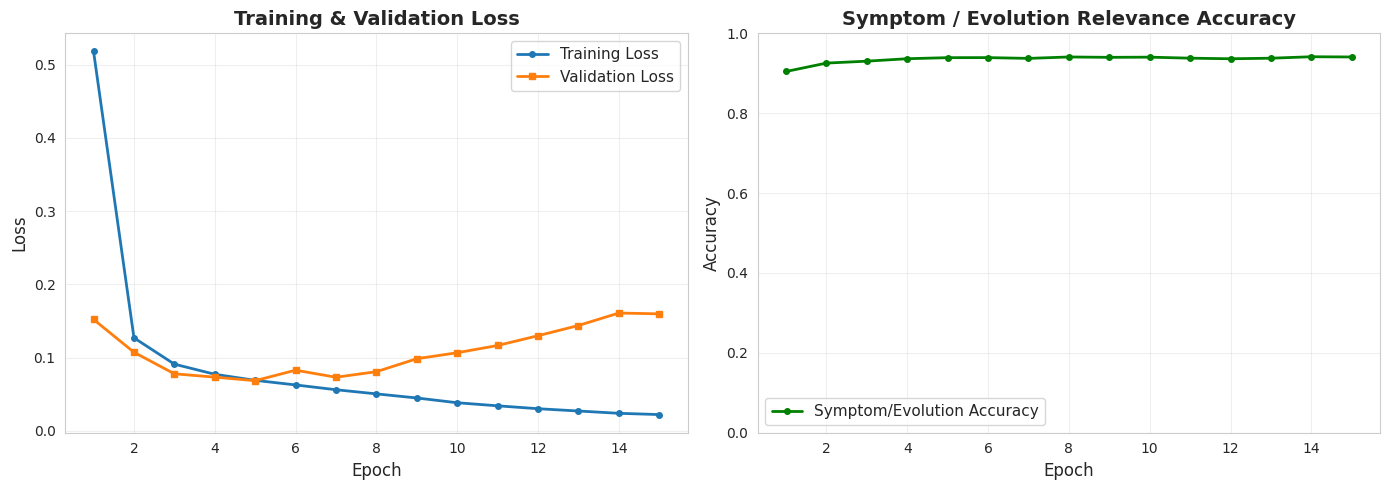

✓ Training progress saved to /data/Stagewise Dataset/MedProc/final5/training_progress.png


In [ ]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0].plot(epochs_range, history['train_loss'], label='Training Loss',   linewidth=2, marker='o', markersize=4)
axes[0].plot(epochs_range, history['val_loss'],   label='Validation Loss', linewidth=2, marker='s', markersize=4)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss',  fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Symptom / Evolution relevance accuracy
axes[1].plot(epochs_range, history['val_sym_acc'], label='Symptom/Evolution Accuracy',
             linewidth=2, marker='o', markersize=4, color='green')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Symptom / Evolution Relevance Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'training_progress.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Training progress saved to {OUTPUT_DIR}/training_progress.png')


## Section 6: Visualize Predictions

Sample predictions and confidence scores from the validation set.

=== SAMPLE PREDICTIONS ===

Sample 1:
  Text     : HOSPITAL COURSE: As above the patient presented to with complaints of fever with chills, nausea and abdominal pain. The ...
  True ICD : 2869
  Top-3 ICD predictions:
    1. 0389: 0.055
    2. 41401: 0.050
    3. 51881: 0.046
  Symptom keywords : ['increasing', 'tender', 'fever', 'nausea', 'vomiting']
  Symptom label    : Relevant

Sample 2:
  Text     : Hospital Course: She was admitted to the Trauma service. Neurosurgery was consulted for her spine fractures which were m...
  True ICD : 4019
  Top-3 ICD predictions:
    1. 41401: 0.197
    2. 42731: 0.044
    3. 41071: 0.038
  Symptom keywords : ['constipation']
  Symptom label    : Relevant

Sample 3:
  Text     : Hospital Course: This is a 44yoF with history of etoh abuse and chronic pancreatitis w/multiple complications who is tra...
  True ICD : 51881
  Top-3 ICD predictions:
    1. 0389: 0.052
    2. 41401: 0.050
    3. 51881: 0.046
  Symptom keywords : ['fever', 'diarrhea', 'sc

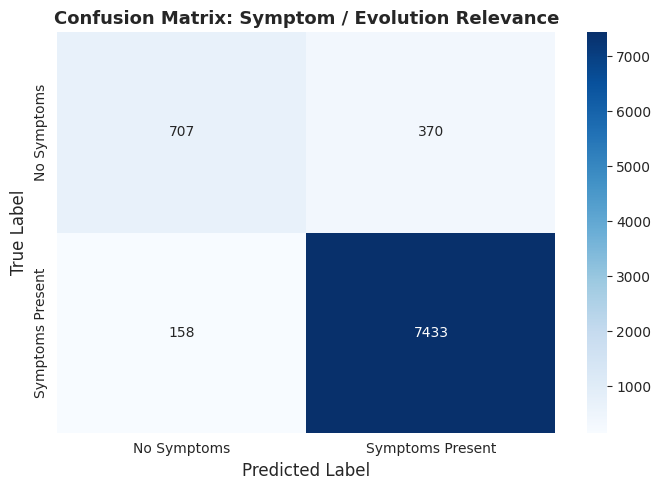

✓ Symptom confusion matrix saved


In [ ]:
# Sample predictions on validation set
print('=== SAMPLE PREDICTIONS ===\n')

val_df = df.iloc[val_idx].reset_index(drop=True)
sample_indices = np.random.choice(len(val_df), min(3, len(val_df)), replace=False)

for i, idx in enumerate(sample_indices, 1):
    print(f'Sample {i}:')
    text = val_df.iloc[idx]['TEXT']
    print(f'  Text     : {text[:120]}...')
    print(f'  True ICD : {val_df.iloc[idx]["icd_prefix"]}')

    if idx < len(icd_probs_all):
        pred_probs  = icd_probs_all[idx]
        top_k       = np.argsort(-pred_probs)[:3]
        print(f'  Top-3 ICD predictions:')
        for rank, class_idx in enumerate(top_k, 1):
            if class_idx < len(mlb.classes_):
                print(f'    {rank}. {mlb.classes_[class_idx]}: {pred_probs[class_idx]:.3f}')

        # Rule-based symptom extraction (what will feed evolution_score in Stage 6)
        kws = extract_symptoms_from_text(text)
        print(f'  Symptom keywords : {kws[:5] if kws else "None detected"}')
        print(f'  Symptom label    : {"Relevant" if sym_preds_all[idx] else "Not relevant"}')
    else:
        print(f'  ⚠️  Prediction data not available for index {idx}')
    print()

# Confusion matrix for symptom / evolution relevance
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(sym_true_all.flatten(), sym_preds_all.flatten())

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
            xticklabels=['No Symptoms', 'Symptoms Present'],
            yticklabels=['No Symptoms', 'Symptoms Present'])
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_title('Confusion Matrix: Symptom / Evolution Relevance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'symptom_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Symptom confusion matrix saved')


In [ ]:
# Save final checkpoint with metadata
print('Saving checkpoint...')

label_map  = {i: label for i, label in enumerate(mlb.classes_)}
thresholds = {
    'icd':     0.35,   # min confidence to report an ICD prediction
    'symptom': 0.30,   # min confidence to flag symptom/evolution relevance
}

save_checkpoint(
    model, tokenizer, label_map, SYMPTOM_KEYWORDS, thresholds,
    str(CHECKPOINT_DIR / 'medproc_checkpoint.pt')
)

print(f'\n=== TRAINING SUMMARY ===')
print(f'Model              : {MODEL_NAME}')
print(f'Epochs trained     : {EPOCHS}')
print(f'Batch size         : {BATCH_SIZE}')
print(f'Learning rate      : {LR}')
print(f'Best val loss      : {min(history["val_loss"]):.4f}')
print(f'Final sym accuracy : {history["val_sym_acc"][-1]:.3f}')
print(f'ICD classes        : {NUM_ICD_LABELS}')
print(f'Checkpoint         : {CHECKPOINT_DIR}')
print(f'Artifacts:')
print(f'  medproc_best.pt           — best model weights')
print(f'  medproc_checkpoint.pt     — complete checkpoint (weights + tokenizer + metadata)')
print(f'  training_progress.png     — loss + symptom accuracy curves')
print(f'  symptom_confusion_matrix.png — symptom relevance confusion matrix')
print(f'\nOutputs for IT-Fusion (Stage 6):')
print(f'  evolution_score   — derived from symptom_head + keyword extraction')
print(f'  symptom_keywords  — from extract_symptoms_from_text()')


Saving checkpoint...
✓ Checkpoint saved to /data/Stagewise Dataset/MedProc/checkpoints/medproc_checkpoint.pt

=== TRAINING SUMMARY ===
Model              : emilyalsentzer/Bio_ClinicalBERT
Epochs trained     : 50
Batch size         : 16
Learning rate      : 2e-05
Best val loss      : 0.0684
Final sym accuracy : 0.941
ICD classes        : 782
Checkpoint         : /data/Stagewise Dataset/MedProc/checkpoints
Artifacts:
  medproc_best.pt           — best model weights
  medproc_checkpoint.pt     — complete checkpoint (weights + tokenizer + metadata)
  training_progress.png     — loss + symptom accuracy curves
  symptom_confusion_matrix.png — symptom relevance confusion matrix

Outputs for IT-Fusion (Stage 6):
  evolution_score   — derived from symptom_head + keyword extraction
  symptom_keywords  — from extract_symptoms_from_text()


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# END-TO-END DEMO: How the trained model predicts on a new clinical note
# Shows every output that Stage 5 (MedProc) feeds into IT-Fusion (Stage 6)
# ─────────────────────────────────────────────────────────────────────────────

import torch
import numpy as np

# ── Load best checkpoint ───────────────────────────────────────────────────
print('Loading best checkpoint...')
ckpt = load_checkpoint(str(CHECKPOINT_DIR / 'medproc_checkpoint.pt'), device=DEVICE)

# Normalise label_map keys to strings (saved as int in some checkpoints)
inf_label_map = {str(k): v for k, v in ckpt['label_map'].items()}

inf_model     = MedProcMultiTaskModel(MODEL_NAME, len(inf_label_map)).to(DEVICE)
inf_model.load_state_dict(ckpt['model_state'])
inf_model.eval()

inf_tokenizer     = ckpt['tokenizer']
inf_sym_keywords  = ckpt['symptom_keywords']
ICD_THRESHOLD     = ckpt['icd_threshold']    # 0.35 — production threshold
SYM_THRESHOLD     = ckpt['sym_threshold']    # 0.30
DISPLAY_THRESHOLD = 0.03                     # lower threshold for demo readability

print(f'✓ Model loaded — {len(inf_label_map)} ICD classes')
print(f'  ICD threshold (production) : {ICD_THRESHOLD}')
print(f'  ICD threshold (demo)       : {DISPLAY_THRESHOLD}')
print(f'  Sym threshold              : {SYM_THRESHOLD}')


# ── Inference function ─────────────────────────────────────────────────────
def predict_medproc(clinical_note: str, patient_gender: str = 'M') -> dict:
    """
    Full MedProc inference on one clinical note.

    Returns a structured dict with everything Stage 6 (IT-Fusion) needs:
      - diagnoses        : ranked ICD predictions with confidence
      - symptom_keywords : matched evolution/symptom keywords (rule-based)
      - evolution_E      : score + severity + signal breakdown
      - symptom_relevant : whether the symptom head flagged this note (model)
    """
    # ── 1. Preprocess ─────────────────────────────────────────────────────
    cleaned   = clean_text(clinical_note)
    truncated = smart_truncate(cleaned, MAX_TEXT_LENGTH)

    # ── 2. Tokenize ───────────────────────────────────────────────────────
    enc = inf_tokenizer(
        truncated,
        max_length=MAX_SEQ_LEN,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )
    input_ids      = enc['input_ids'].to(DEVICE)
    attention_mask = enc['attention_mask'].to(DEVICE)

    # ── 3. Model forward pass ─────────────────────────────────────────────
    with torch.no_grad():
        icd_logits, sym_logits = inf_model(input_ids, attention_mask)

    icd_probs = torch.sigmoid(icd_logits).cpu().numpy().flatten()  # [num_icd_classes]
    sym_score = torch.sigmoid(sym_logits).squeeze().item()         # scalar 0-1
    sym_flag  = sym_score >= SYM_THRESHOLD

    # ── 4. Ranked ICD predictions ─────────────────────────────────────────
    top_indices = np.argsort(-icd_probs)
    diagnoses   = []
    for idx in top_indices[:10]:
        conf = float(icd_probs[idx])
        if conf >= DISPLAY_THRESHOLD or len(diagnoses) < 3:
            key = str(int(idx))
            diagnoses.append({
                'icd_prefix': inf_label_map.get(key, f'IDX_{idx}'),
                'confidence': round(conf, 4),
                'above_prod_threshold': conf >= ICD_THRESHOLD,
            })
        else:
            break

    # ── 5. Rule-based evolution signal extraction ────────────────────────
    # Uses full SYMPTOM_KEYWORDS for runtime keyword list (boost scoring)
    # These are passed to compute_evolution() in abcde_computation.py
    kws = extract_symptoms_from_text(truncated)

    # ── 6. Evolution E score — ALIGNED with abcde_computation.py ─────────
    # Formula matches compute_evolution():
    #   base_score = sym_score (from neural symptom_head)
    #   keyword_boost = 0.05 per matched EVOLUTION keyword, capped at 0.25
    # This is what actually reaches ABCDE computation in production.
    HIGH_CONCERN = {
        'grew', 'growth', 'larger', 'spreading', 'increased size',
        'bleed', 'bleeding', 'oozing', 'colour change', 'color change',
        'new lesion', 'rapid', 'ulcerated',
    }
    import re as _re
    boost = 0.0; matched_kws = []
    for kw in kws:
        kw_l = kw.lower()
        if _re.search(r'\b(no|not|without|denies)\b', kw_l): continue
        for hkw in HIGH_CONCERN:
            if _re.search(r'\b' + _re.escape(hkw) + r'\b', kw_l):
                boost += 0.05; matched_kws.append(kw); break
    boost = min(boost, 0.25)
    evo_score = float(min(1.0, sym_score + boost))   # neural + keyword boost
    evo_severity = ('High'     if evo_score > 0.6 else
                    'Moderate' if evo_score > 0.3 else 'Low')
    # Categorise matched keywords for display
    progression = [k for k in matched_kws if any(t in k.lower() for t in
                    ['grow', 'spread', 'enlarg', 'increas'])]
    skin_change = [k for k in matched_kws if any(t in k.lower() for t in
                    ['bleed', 'oozing', 'color', 'colour', 'ulcer'])]
    temporal    = [k for k in kws if any(t in k for t in
                    ['lesion for', 'spot for', 'mole for', 'growth for',
                     'developed over', 'appeared over', 'gradual change', 'sudden change'])]

    return {
        'patient':             {'gender': patient_gender},
        'input_length':        len(clinical_note),
        'cleaned_length':      len(truncated),
        'diagnoses':           diagnoses,
        'symptom_keywords':    kws,
        'evolution_keywords':  matched_kws,  # keywords that boosted E score
        'symptom_relevant':    bool(sym_flag),
        'symptom_model_score': round(sym_score, 4),
        'evolution_E': {
            'score':       round(evo_score, 4),
            'severity':    evo_severity,
            'temporal':    temporal,
            'progression': progression,
            'skin_change': skin_change,
        },
    }


# ── Demo clinical notes ───────────────────────────────────────────────────
DEMO_NOTES = [
    {
        'label': 'High-risk melanoma suspect',
        'gender': 'M',
        'note': """
        58-year-old male admitted for evaluation of rapidly growing pigmented lesion
        on left forearm. Patient reports the lesion has been enlarging over the past
        3 months with progressive color change from brown to black. Itching and
        occasional bleeding noted. Border irregularity and asymmetry observed on
        dermoscopy. Family history of melanoma (father). No prior skin cancers.
        Assessment: Highly suspicious for melanoma. Plan: Urgent dermatology referral,
        excisional biopsy scheduled. ICD: 172.6
        """
    },
    {
        'label': 'Routine hypertension — no skin findings',
        'gender': 'F',
        'note': """
        72-year-old female with known hypertension and type 2 diabetes presenting
        for routine follow-up. Blood pressure well controlled on lisinopril 10mg
        daily and amlodipine 5mg. HbA1c 7.1%. No complaints today. No skin lesions
        noted on examination. Refills provided. Return in 3 months.
        Assessment: Stable hypertension and diabetes. ICD: 4011
        """
    },
    {
        'label': 'Eczema with evolution signals',
        'gender': 'F',
        'note': """
        34-year-old female with worsening eczema on bilateral arms and trunk.
        Reports flare has been spreading over 6 weeks despite topical steroids.
        Severe pruritus and itching, worse at night. Erythema and scaling present.
        No fever. History of atopic dermatitis since childhood.
        Assessment: Atopic dermatitis flare, moderate-severe. Plan: Switch to
        tacrolimus ointment, add oral antihistamine. ICD: 6919
        """
    },
]


# ── Run and display ───────────────────────────────────────────────────────
DIVIDER  = '═' * 70
SEV_ICON = {'High': '🔴', 'Moderate': '🟡', 'Low': '🟢'}

all_results = []
for demo in DEMO_NOTES:
    result = predict_medproc(demo['note'], demo['gender'])
    all_results.append(result)

    print(f'\n{DIVIDER}')
    print(f"  CASE : {demo['label']}  |  Gender: {demo['gender']}")
    print(DIVIDER)
    print(f"  Text : {result['input_length']} chars  →  after clean/truncate: {result['cleaned_length']} chars")

    # ICD predictions
    print(f"\n  ── ICD Predictions (prod threshold: {ICD_THRESHOLD} | shown from: {DISPLAY_THRESHOLD}) ──")
    for rank, dx in enumerate(result['diagnoses'], 1):
        bar    = '█' * int(dx['confidence'] * 40)
        marker = ' ★' if dx['above_prod_threshold'] else ''
        print(f"    {rank}. ICD {dx['icd_prefix']:<10} {bar:<20} {dx['confidence']:.4f}{marker}")
    print(f"         (★ = above production threshold {ICD_THRESHOLD})")

    # Symptom head
    print(f"\n  ── Symptom Head Output (neural model) ──")
    flag_str = '✓ RELEVANT' if result['symptom_relevant'] else '✗ not relevant'
    print(f"    Result  : {flag_str}")
    print(f"    Score   : {result['symptom_model_score']:.4f}  (threshold: {SYM_THRESHOLD})")

    # Rule-based keywords
    print(f"\n  ── Keyword Extraction (rule-based) ──")
    kws = result['symptom_keywords']
    print(f"    All matched : {kws if kws else 'None'}")
    print(f"    Temporal    : {result['evolution_E']['temporal']}")
    print(f"    Progression : {result['evolution_E']['progression']}")
    print(f"    Skin change : {result['evolution_E']['skin_change']}")

    # Evolution E score
    evo = result['evolution_E']
    print(f"\n  ── Evolution E Score → IT-Fusion (Stage 6) ──")
    print(f"    E score  : {evo['score']:.4f}")
    print(f"    Severity : {SEV_ICON[evo['severity']]} {evo['severity']}")
    print(f"    Breakdown:")
    print(f"      temporal    ({len(evo['temporal'])} signal/s)   × 0.40 = {0.4 * min(1,len(evo['temporal'])):.2f}")
    print(f"      progression ({len(evo['progression'])} signal/s) × 0.40 = {0.4 * min(1,len(evo['progression'])):.2f}")
    print(f"      skin_change ({len(evo['skin_change'])} signal/s) × 0.20 = {0.2 * min(1,len(evo['skin_change'])):.2f}")
    print(f"                                           ──────")
    print(f"      E score total                              {evo['score']:.4f}")

    print(f"\n  ── Output JSON for IT-Fusion ──")
    print(f"    evolution_score  : {evo['score']}")
    print(f"    symptom_keywords : {kws[:6]}{'...' if len(kws) > 6 else ''}")

print(f'\n{DIVIDER}')
print('  DEMO COMPLETE')
print(f'{DIVIDER}')

# ── Summary table ─────────────────────────────────────────────────────────
print('\n\n  SUMMARY')
print(f"  {'Case':<42} {'Top ICD':<10} {'Conf':<8} {'E Score':<10} {'Severity':<10} {'Sym'}")
print(f"  {'-'*42} {'-'*10} {'-'*8} {'-'*10} {'-'*10} {'-'*5}")
for demo, res in zip(DEMO_NOTES, all_results):
    top = res['diagnoses'][0]
    evo = res['evolution_E']
    sym = '✓' if res['symptom_relevant'] else '✗'
    print(f"  {demo['label']:<42} {top['icd_prefix']:<10} {top['confidence']:<8.4f} "
          f"{evo['score']:<10.4f} {evo['severity']:<10} {sym}")

Loading best checkpoint...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ Model loaded — 782 ICD classes
  ICD threshold (production) : 0.35
  ICD threshold (demo)       : 0.03
  Sym threshold              : 0.3

══════════════════════════════════════════════════════════════════════
  CASE : High-risk melanoma suspect  |  Gender: M
══════════════════════════════════════════════════════════════════════
  Text : 555 chars  →  after clean/truncate: 489 chars

  ── ICD Predictions (prod threshold: 0.35 | shown from: 0.03) ──
    1. ICD 41401      ██                   0.0562
    2. ICD 0389       ██                   0.0513
    3. ICD 51881      █                    0.0456
    4. ICD 5849       █                    0.0369
         (★ = above production threshold 0.35)

  ── Symptom Head Output (neural model) ──
    Result  : ✓ RELEVANT
    Score   : 0.9995  (threshold: 0.3)

  ── Keyword Extraction (rule-based) ──
    All matched : ['growing', 'enlarging', 'bleeding', 'itching', 'color change']
    Temporal    : []
    Progression : []
    Skin change : ['bleed